In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

In [2]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(
        os.path.join("dataset", sub_folder)
    )

    for filename in sub_folder_files:

        img_path = os.path.join(
            "dataset",
            sub_folder,
            filename
        )

        img = cv.imread(img_path)

        if img is None:
            print(f"Gagal membaca: {img_path}")
            continue

        img = img.astype(np.uint8)

        # grayscale
        img = cv.cvtColor(
            img,
            cv.COLOR_BGR2GRAY
        )

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)

In [3]:
print(f"Jumlah data asli : {len(data)}")

Jumlah data asli : 840


## Visualisasi Sebelum Preprocessing 2

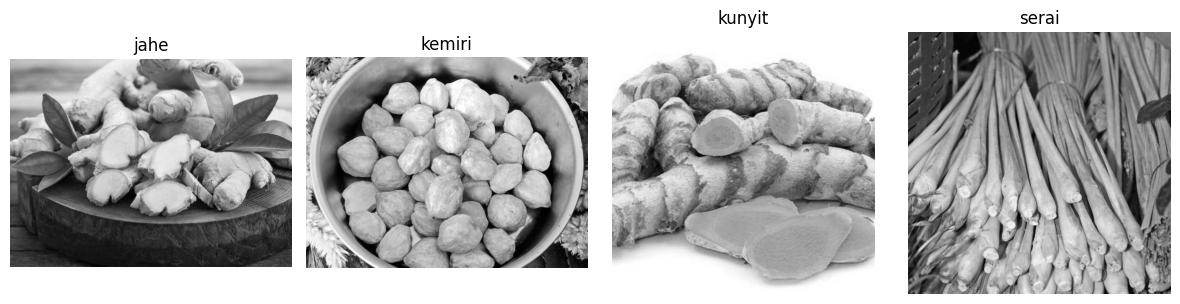

In [4]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    idx = np.where(labels == kelas)[0][0]

    plt.subplot(1, 4, i + 1)
    plt.imshow(data[idx], cmap="gray")
    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation

In [5]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):

    img = data[i]
    label = labels[i]
    fname = file_name[i]

    name, ext = os.path.splitext(fname)

    # gambar asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)

    # flip horizontal
    flip_h = cv.flip(img, 1)
    data_augmented.append(flip_h)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipH" + ext
    )

    # flip vertikal
    flip_v = cv.flip(img, 0)
    data_augmented.append(flip_v)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_flipV" + ext
    )

    # rotasi 90 derajat
    rot_90 = cv.rotate(
        img,
        cv.ROTATE_90_CLOCKWISE
    )
    data_augmented.append(rot_90)
    labels_augmented.append(label)
    file_name_augmented.append(
        name + "_rot90" + ext
    )

data_augmented = np.array(
    data_augmented,
    dtype=object
)

labels_augmented = np.array(
    labels_augmented
)

In [6]:
print("Data sebelum augmentasi :", len(data))
print("Data setelah augmentasi :", len(data_augmented))

Data sebelum augmentasi : 840
Data setelah augmentasi : 3360


## Data Preparation

### Percobaan 1 + Median Filter + Histogram Equalization

In [7]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros((new_height, new_width),
                             dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

In [8]:
def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape, dtype=np.uint8)
    return (
        (image - min_val) /
        (max_val - min_val) * 255
    ).astype(np.uint8)

In [9]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)

                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter(foto_karim, 3, 'mean')

In [10]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)

    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(
        cdf * 255 / (height * width)
    ).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Mapping pixel menggunakan CDF
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

In [11]:
def prepro2(image):
    image = resize(image, 224, 224)
    image = normalisasi(image)
    image = filter_citra(image, 3, 'median')
    image = ekualisasi(image)

    return image

In [12]:
data_preprocessed = []

for i in range(len(data_augmented)):

    img = prepro2(
        data_augmented[i]
    )

    data_preprocessed.append(img)

data_preprocessed = np.array(
    data_preprocessed,
    dtype=np.uint8
)

print(data_preprocessed.shape)

(3360, 224, 224)


## Visualisasi Hasil Preprocessing 2

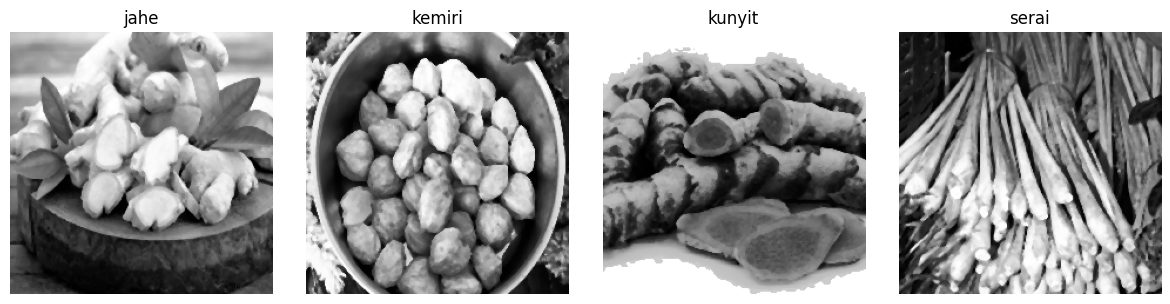

In [13]:
plt.figure(figsize=(12, 3))

unique_labels = np.unique(labels)

for i, kelas in enumerate(unique_labels):

    idx = np.where(
        labels == kelas
    )[0][0]

    img = prepro2(
        data[idx]
    )

    plt.subplot(
        1,
        4,
        i + 1
    )

    plt.imshow(
        img,
        cmap="gray"
    )

    plt.title(kelas)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [15]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(data)):
    D0   = glcm(data[i], 0)
    D45  = glcm(data[i], 45)
    D90  = glcm(data[i], 90)
    D135 = glcm(data[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(data)}")

   Progress: 100/840
   Progress: 200/840
   Progress: 300/840
   Progress: 400/840
   Progress: 500/840
   Progress: 600/840
   Progress: 700/840
   Progress: 800/840


In [16]:
Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(data)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [17]:

# Buat dictionary semua fitur
dataTable = {
    'Filename' : file_name,
    'Label'    : labels,
    # GLCM Features
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
print(f"   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'")
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'
   Shape DataFrame: (840, 30)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,jahe_1.jpg,jahe,46.554922,89.782564,54.931060,93.773968,0.392631,0.271465,0.329488,0.270699,...,0.000455,0.000341,0.023651,0.018525,0.021322,0.018465,0.994192,0.988790,0.993138,0.988291
1,jahe_10.JPG,jahe,84.622903,151.809958,128.279534,171.013164,0.563951,0.520018,0.533081,0.515770,...,0.178349,0.173943,0.428282,0.417857,0.422313,0.417065,0.971143,0.948359,0.956310,0.941826
2,jahe_100.jpg,jahe,18.938777,37.923179,19.992784,36.840915,0.642701,0.532900,0.605164,0.535536,...,0.058726,0.056064,0.242634,0.236653,0.242335,0.236779,0.996096,0.992180,0.995878,0.992403
3,jahe_101.jpg,jahe,114.991194,255.353886,144.379891,258.426928,0.500681,0.368097,0.419382,0.362660,...,0.001334,0.001215,0.039394,0.035027,0.036529,0.034853,0.988079,0.973479,0.985013,0.973160
4,jahe_102.jpg,jahe,37.520034,219.579673,190.365542,224.386255,0.513482,0.442283,0.490638,0.434809,...,0.030014,0.026582,0.178128,0.163008,0.173245,0.163041,0.993280,0.960045,0.965362,0.959170


In [18]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 11
Fitur yang dipilih    : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


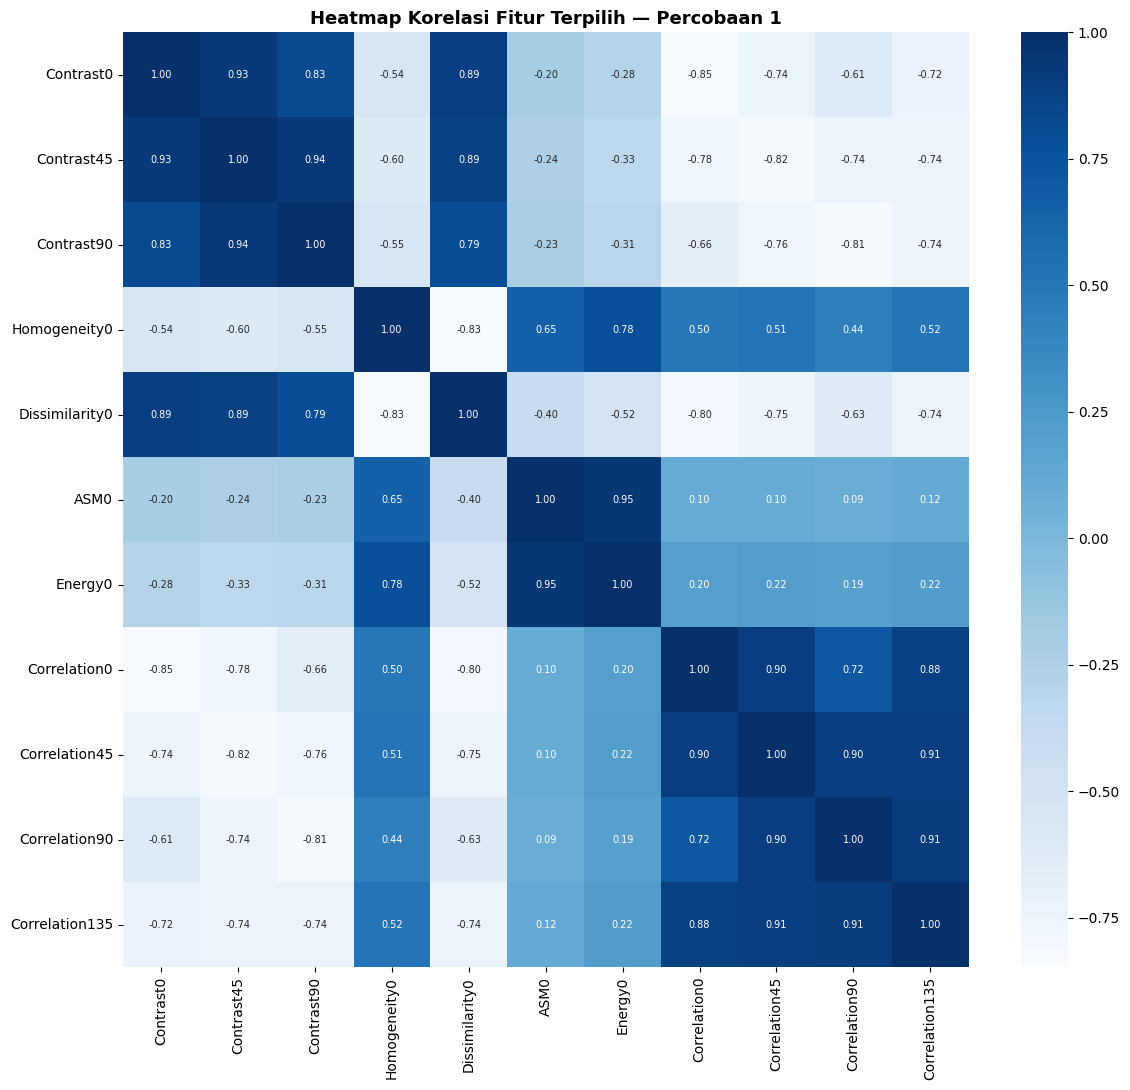

In [19]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

train_mean = X_train.mean()
train_std  = X_train.std()

# Hindari pembagian dengan nol
train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print("Normalisasi Z-Score selesai!")
print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

Normalisasi Z-Score selesai!
   X_train setelah normalisasi: mean ≈ 0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ -0.0338


In [21]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

print("Model berhasil didefinisikan!")
print("   - Random Forest  : n_estimators=100")
print("   - SVM            : kernel=RBF, C=1.0")
print("   - KNN            : n_neighbors=5")

Model berhasil didefinisikan!
   - Random Forest  : n_estimators=100
   - SVM            : kernel=RBF, C=1.0
   - KNN            : n_neighbors=5


In [22]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

        jahe       1.00      1.00      1.00       168
      kemiri       1.00      1.00      1.00       168
      kunyit       1.00      1.00      1.00       168
       serai       1.00      1.00      1.00       168

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

        jahe       0.53      0.50      0.51        42
      kemiri       0.62      0.67      0.64        42
      kunyit       0.59      0.64      0.61        42
       serai       0.73      0.64      0.68        42

    accuracy                           0.61       168
   macro avg    

In [23]:
print("\n  SVM CLASSIFIER")
print("="*55)

svm.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_svm_train = svm.predict(X_train_norm)
svm_train_acc, svm_train_prec, svm_train_rec, svm_train_f1 = generateClassificationReport(
    y_train, y_pred_svm_train, "SVM — Training Set")

print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


  SVM CLASSIFIER

---------- Training Set ----------

  SVM — Training Set
              precision    recall  f1-score   support

        jahe       0.61      0.35      0.44       168
      kemiri       0.46      0.60      0.52       168
      kunyit       0.49      0.68      0.57       168
       serai       0.75      0.55      0.64       168

    accuracy                           0.54       672
   macro avg       0.58      0.54      0.54       672
weighted avg       0.58      0.54      0.54       672

  Accuracy  : 0.5446
  Precision : 0.5772
  Recall    : 0.5446
  F1-Score  : 0.5417

---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

        jahe       0.57      0.31      0.40        42
      kemiri       0.44      0.57      0.49        42
      kunyit       0.44      0.64      0.52        42
       serai       0.75      0.50      0.60        42

    accuracy                           0.51       168
   macro avg       0.55

In [24]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")

print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

        jahe       0.64      0.70      0.67       168
      kemiri       0.60      0.72      0.65       168
      kunyit       0.66      0.61      0.63       168
       serai       0.87      0.66      0.75       168

    accuracy                           0.67       672
   macro avg       0.69      0.67      0.68       672
weighted avg       0.69      0.67      0.68       672

  Accuracy  : 0.6741
  Precision : 0.6910
  Recall    : 0.6741
  F1-Score  : 0.6768

---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

        jahe       0.46      0.40      0.43        42
      kemiri       0.41      0.57      0.48        42
      kunyit       0.62      0.67      0.64        42
       serai       0.68      0.45      0.54        42

    accuracy                           0.52       168
   macro avg       0.54 

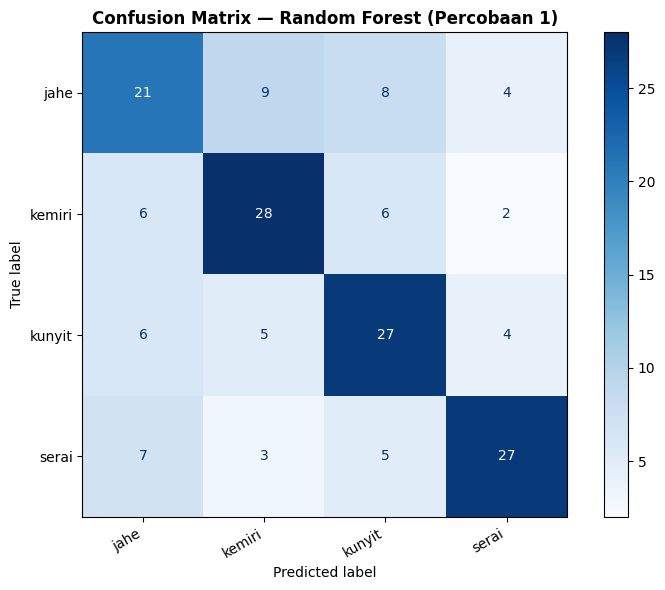

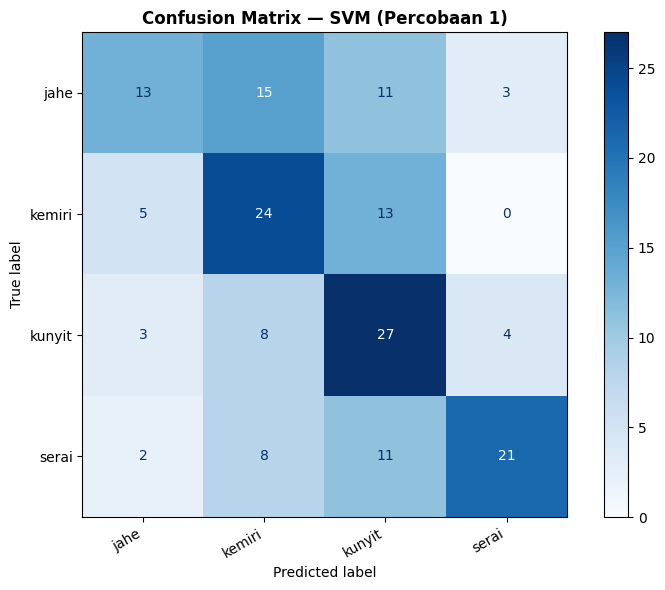

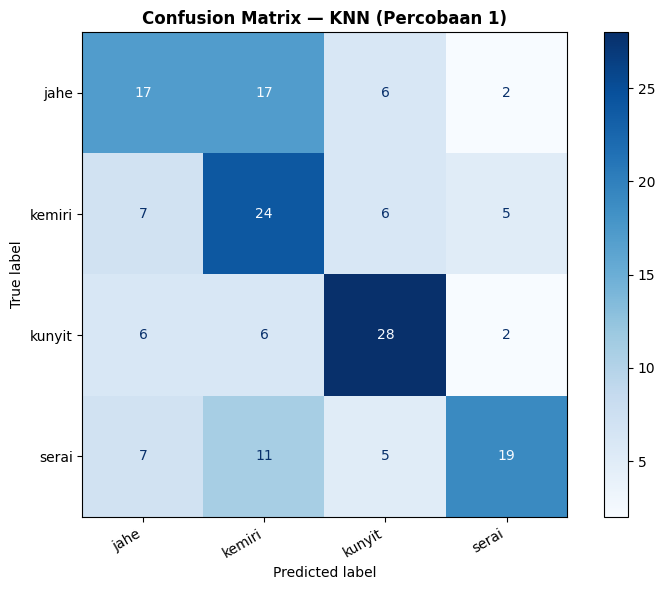

In [25]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 1)")